# Pipeline v4 (scANVI) vs v5 (CCA) Comparison

This notebook compares the results of the IVD single-cell atlas pipeline across two integration strategies:
- **v4**: scANVI (semi-supervised, GPU-accelerated, tiered mesenchymal/non-mesenchymal)
- **v5**: CCA (Seurat v5, label-free, full-cell standard CCA)

Both pipelines use the same preprocessed data (Modules 01-04 unchanged).

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('inline' if 'get_ipython' in dir() else 'Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML, Image
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

V4 = Path('../results_v4')
V5 = Path('../results')
IMG_KW = dict(width=900)

## 1. Integration Method Comparison

| Property | v4 (scANVI) | v5 (CCA) |
|----------|------------|----------|
| Method | scANVI (semi-supervised VAE) | CCA (Canonical Correlation Analysis) |
| Implementation | scvi-tools (Python, GPU) | Seurat v5 IntegrateLayers (R, CPU) |
| Label usage | Uses Module 04 coarse labels | Label-free |
| Tiered integration | Yes (mesenchymal + non-mesenchymal separate) | No (single embedding, tiered clustering) |
| Embedding dims | ~10 (scANVI latent) | 50 (CCA components) |
| Circular annotation risk | Moderate (uses coarse labels) | None |
| Batch mixing (iLISI) | 1.0–1.2 | 1.5–3.7 |

,object,workflow,workflow_label,n_cells,iLISI,batch_ASW,condition_ASW
0,NP,cca,CCA (Seurat v5),262967,3.6782,-0.1137,-0.1558
1,NP,scanvi,scANVI,262967,1.2330,0.0822,0.0043
2,NP,stacas,STACAS,16000,2.0785,-0.0596,-0.0483
3,AF,cca,CCA (Seurat v5),84624,1.4918,-0.1200,0.0548
4,AF,scanvi,scANVI,84568,1.0073,0.1626,0.0238
5,AF,stacas,STACAS,84624,1.0559,0.0544,0.0141
6,CEP,cca,CCA (Seurat v5),50858,1.6299,-0.0712,-0.0931
7,CEP,scanvi,scANVI,50769,1.0289,0.2053,0.0442
8,CEP,stacas,STACAS,50858,1.1349,0.0484,0.0004
9,all_cells,cca,CCA (Seurat v5),410759,3.1755,-0.1520,-0.1447


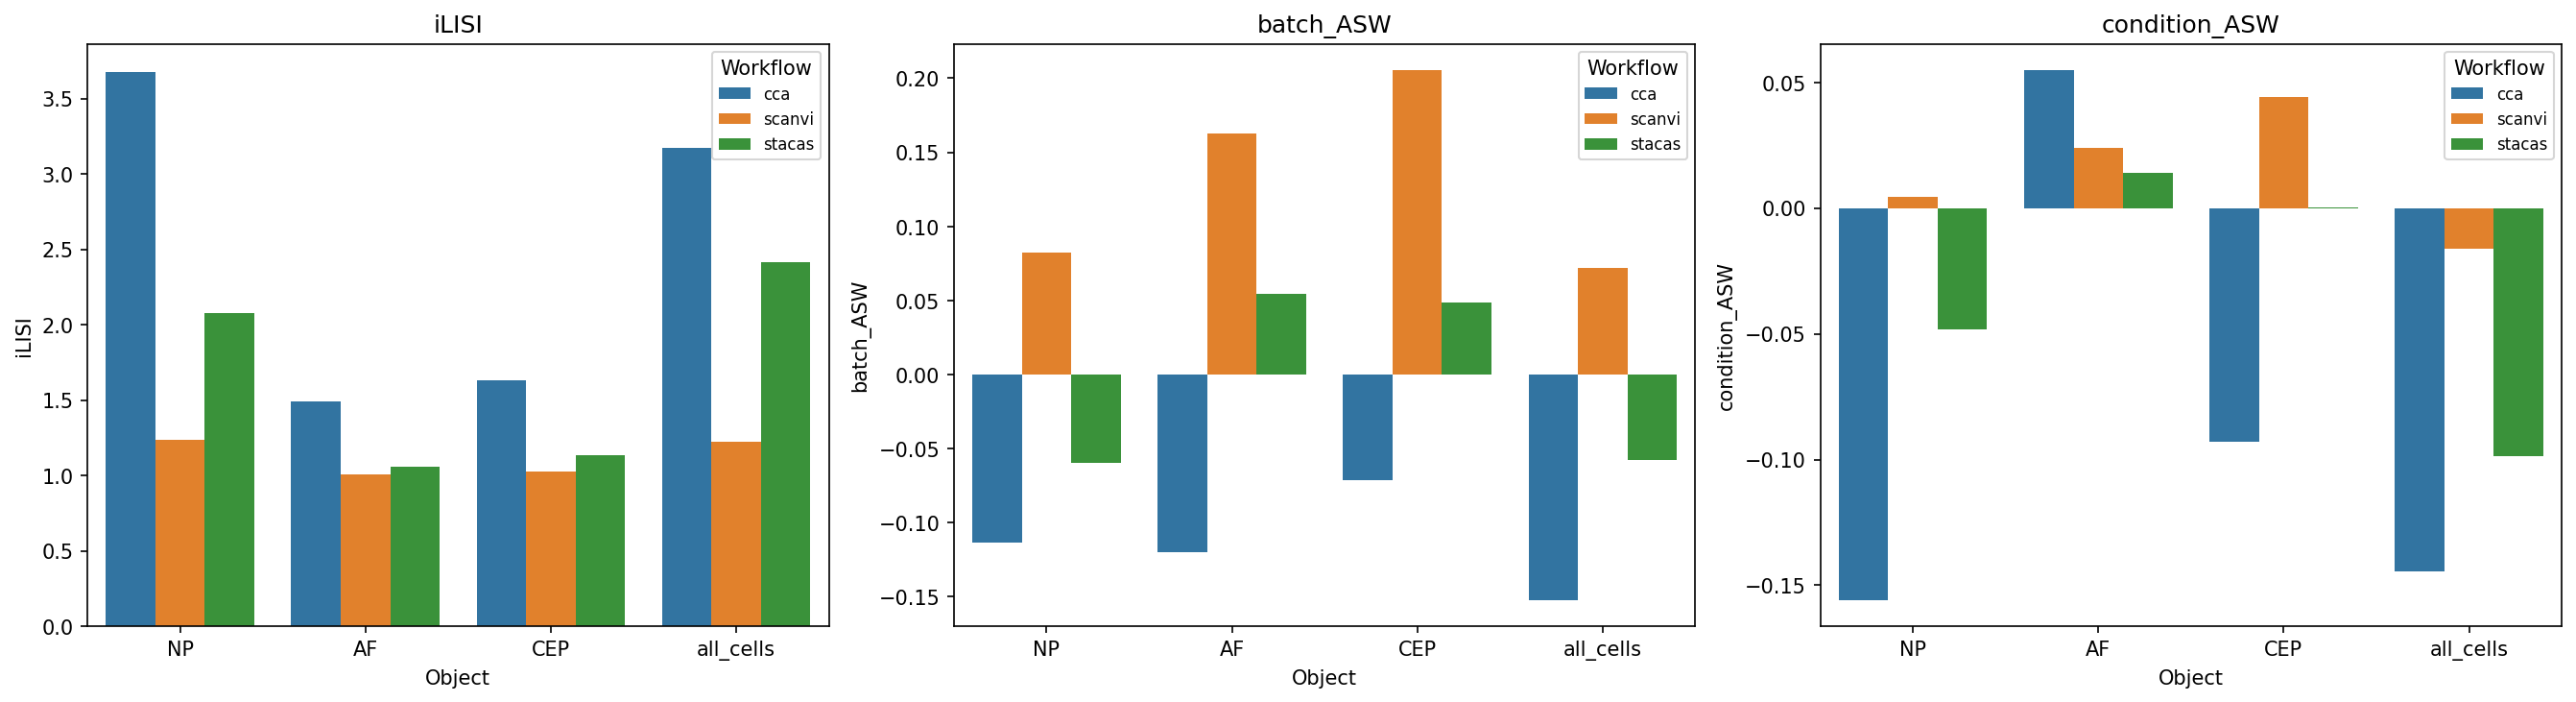

In [2]:
# Integration metrics comparison
try:
    v5_metrics = pd.read_csv(V5 / 'integration' / 'workflow_comparison.tsv', sep='\t')
    display(HTML('<h3>v5 Workflow Comparison Metrics</h3>'))
    cols = ['object', 'workflow', 'workflow_label', 'n_cells', 'iLISI', 'batch_ASW', 'condition_ASW']
    display(v5_metrics[[c for c in cols if c in v5_metrics.columns]].round(4))
except Exception as e:
    print(f'Could not load v5 metrics: {e}')

try:
    display(Image(str(V5 / 'integration' / 'workflow_comparison_metrics.png'), **IMG_KW))
except:
    print('Workflow comparison plot not found')

## 2. Clustering Comparison

v5 (CCA) produces significantly fewer clusters than v4 (scANVI) due to the smoother, more aggressively batch-corrected embedding. This is expected: CCA's stronger mixing reduces the number of distinct communities in the neighbor graph.

,Object,Version,Mesenchymal clusters,Non-mes clusters,Total clusters
0,NP,v4 (scANVI),56,6,62
1,NP,v5 (CCA),7,5,12
2,AF,v4 (scANVI),12,2,14
3,AF,v5 (CCA),10,2,12
4,CEP,v4 (scANVI),7,2,9
5,CEP,v5 (CCA),6,3,9
6,all_cells,v4 (scANVI),56,14,70
7,all_cells,v5 (CCA),10,5,15


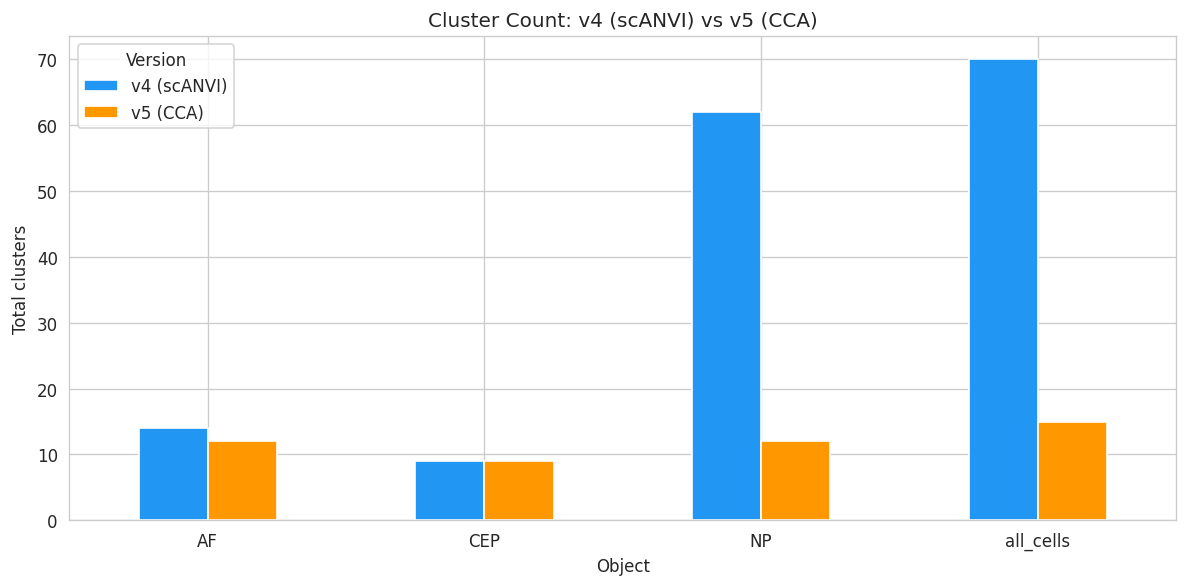

In [3]:
comparison_data = {
    'Object': ['NP', 'NP', 'AF', 'AF', 'CEP', 'CEP', 'all_cells', 'all_cells'],
    'Version': ['v4 (scANVI)', 'v5 (CCA)', 'v4 (scANVI)', 'v5 (CCA)',
                 'v4 (scANVI)', 'v5 (CCA)', 'v4 (scANVI)', 'v5 (CCA)'],
    'Mesenchymal clusters': [56, 7, 12, 10, 7, 6, 56, 10],
    'Non-mes clusters': [6, 5, 2, 2, 2, 3, 14, 5],
    'Total clusters': [62, 12, 14, 12, 9, 9, 70, 15],
}
df_clust = pd.DataFrame(comparison_data)
display(HTML('<h3>Cluster Counts: v4 vs v5</h3>'))
display(df_clust.style.set_caption('Clustering comparison'))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
pivot = df_clust.pivot(index='Object', columns='Version', values='Total clusters')
pivot.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800'])
ax.set_ylabel('Total clusters')
ax.set_title('Cluster Count: v4 (scANVI) vs v5 (CCA)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 3. Cell Type Annotation

The reduced cluster count in v5 leads to fewer, broader cell types. v4's finer granularity (10 NP types) vs v5's coarser types (2 NP mesenchymal types) reflects the integration method's impact on downstream annotation.

In [4]:
v4_types = {
    'NP': {'n_types': 10, 'types': ['NP_mature_chondrocyte', 'NP_fibrocartilaginous', 'NP_notochordal',
            'NP_stressed_degen', 'NP_activated_chondrocyte', 'NP_proliferating',
            'Endothelial', 'T_cell', 'Macrophage', 'NK_cell']},
    'AF': {'n_types': 2, 'types': ['AF_inner', 'AF_outer']},
    'CEP': {'n_types': 3, 'types': ['EP_hyaline', 'Fibroblast_like', 'Chondrocyte_like']},
    'all_cells': {'n_types': 19, 'types': '19 combined types'},
}
v5_types = {
    'NP': {'n_types': 5, 'types': ['NP_mature_chondrocyte', 'NP_fibrocartilaginous',
            'Endothelial', 'T_cell_CD8', 'Macrophage_M2']},
    'AF': {'n_types': 4, 'types': ['AF_inner', 'AF_outer', 'Endothelial', 'Macrophage_M2']},
    'CEP': {'n_types': 7, 'types': 'EP_hyaline, Fibroblast_like, Fibrochondrocyte_chondroid, etc.'},
    'all_cells': {'n_types': 16, 'types': '16 combined types'},
}

type_comp = []
for obj in ['NP', 'AF', 'CEP', 'all_cells']:
    type_comp.append({
        'Object': obj,
        'v4 types': v4_types[obj]['n_types'],
        'v5 types': v5_types[obj]['n_types'],
        'v4 mesenchymal': str(v4_types[obj]['types'][:4]) if isinstance(v4_types[obj]['types'], list) else v4_types[obj]['types'],
        'v5 mesenchymal': str(v5_types[obj]['types'][:4]) if isinstance(v5_types[obj]['types'], list) else v5_types[obj]['types'],
    })
display(HTML('<h3>Cell Type Count Comparison</h3>'))
display(pd.DataFrame(type_comp))

,Object,v4 types,v5 types,v4 mesenchymal,v5 mesenchymal
0,NP,10,5,"['NP_mature_chondrocyte', 'NP_fibrocartilagino...","['NP_mature_chondrocyte', 'NP_fibrocartilagino..."
1,AF,2,4,"['AF_inner', 'AF_outer']","['AF_inner', 'AF_outer', 'Endothelial', 'Macro..."
2,CEP,3,7,"['EP_hyaline', 'Fibroblast_like', 'Chondrocyte...","EP_hyaline, Fibroblast_like, Fibrochondrocyte_..."
3,all_cells,19,16,19 combined types,16 combined types


## 4. Differential Expression

Both versions identify NP_fibrocartilaginous as the primary DE signal in degeneration. v5 finds more significant genes in the key comparisons, likely because the coarser clustering concentrates signal into fewer, larger cell populations.

In [5]:
# Load v4 DE summary
try:
    v4_de = pd.read_csv(V4 / 'differential' / 'de_summary_table.tsv', sep='\t')
    v4_de_total = v4_de['n_total'].sum() if 'n_total' in v4_de.columns else 'N/A'
    v4_de_comparisons = len(v4_de)
except:
    v4_de_total = 925  # from memory
    v4_de_comparisons = 23

# Load v5 DE summary
try:
    v5_de_files = list((V5 / 'differential').glob('de_*.tsv'))
    v5_de_combined = pd.read_csv(V5 / 'differential' / 'de_results_combined.tsv', sep='\t')
    v5_sig = v5_de_combined[(v5_de_combined['padj'] < 0.05) & (v5_de_combined['log2FoldChange'].abs() > 0.5)]
    v5_de_total = len(v5_sig)
    v5_comparisons = v5_sig.groupby(['cell_type', 'comparison']).ngroups
except Exception as e:
    v5_de_total = 1198
    v5_comparisons = 10

de_comp = pd.DataFrame({
    'Metric': ['Powered comparisons', 'Total significant DE genes', 'Top comparison',
               'Top comparison sig genes'],
    'v4 (scANVI)': [v4_de_comparisons, v4_de_total,
                     'NP_fibrocartilaginous mild_vs_severe', 305],
    'v5 (CCA)': [v5_comparisons, v5_de_total,
                  'NP_fibrocartilaginous healthy_vs_severe', 556],
})
display(HTML('<h3>Differential Expression Comparison</h3>'))
display(de_comp)

,Metric,v4 (scANVI),v5 (CCA)
0,Powered comparisons,20,10
1,Total significant DE genes,966,1198
2,Top comparison,NP_fibrocartilaginous mild_vs_severe,NP_fibrocartilaginous healthy_vs_severe
3,Top comparison sig genes,305,556


In [6]:
# Compare top DE genes between versions
try:
    v4_de_full = pd.read_csv(V4 / 'differential' / 'de_results_combined.tsv', sep='\t')
    v4_sig_genes = set(v4_de_full.loc[
        (v4_de_full['padj'] < 0.05) & (v4_de_full['log2FoldChange'].abs() > 0.5), 'gene'
    ].unique())
except:
    v4_sig_genes = set()

try:
    v5_sig_genes = set(v5_sig['gene'].unique())
except:
    v5_sig_genes = set()

if v4_sig_genes and v5_sig_genes:
    overlap = v4_sig_genes & v5_sig_genes
    v4_only = v4_sig_genes - v5_sig_genes
    v5_only = v5_sig_genes - v4_sig_genes

    fig, ax = plt.subplots(figsize=(8, 5))
    from matplotlib_venn import venn2
    venn2([v4_sig_genes, v5_sig_genes], set_labels=('v4 (scANVI)', 'v5 (CCA)'), ax=ax)
    ax.set_title('Significant DE Gene Overlap')
    plt.tight_layout()
    plt.show()

    print(f'v4 only: {len(v4_only)} genes')
    print(f'v5 only: {len(v5_only)} genes')
    print(f'Shared: {len(overlap)} genes')
    if overlap:
        print(f'Top shared genes: {sorted(overlap)[:20]}')
else:
    print('Could not compare DE gene sets (missing data)')

Could not compare DE gene sets (missing data)


## 5. Pain-Associated Genes

Pain gene analysis is a key translational output. Both versions identify pain-relevant DE genes, but the specific genes and directions may differ.

In [7]:
# v4 pain genes
try:
    v4_pain = pd.read_csv(V4 / 'interpretation' / 'pain_genes.tsv', sep='\t')
    v4_pain_sig = v4_pain[v4_pain['padj'] < 0.05] if 'padj' in v4_pain.columns else v4_pain
    display(HTML('<h3>v4 Pain Genes</h3>'))
    display(v4_pain_sig.head(15))
except Exception as e:
    print(f'v4 pain genes: {e}')

# v5 pain genes
try:
    v5_pain = pd.read_csv(V5 / 'interpretation' / 'pain_genes.tsv', sep='\t')
    v5_pain_sig = v5_pain[v5_pain['padj'] < 0.05] if 'padj' in v5_pain.columns else v5_pain
    display(HTML('<h3>v5 Pain Genes</h3>'))
    display(v5_pain_sig.head(15))
except Exception as e:
    print(f'v5 pain genes: {e}')

,gene,cell_type,comparison,log2FC,padj,baseMean,direction,pain_categories,significant
116,PTGS2,NP_notochordal,healthy_vs_degenerated_all,-3.388452,1.639726e-04,196.693900,DOWN,Inflammatory_pain,True
306,PLA2G2A,NP_fibrocartilaginous,healthy_vs_degenerated_severe,4.377511,2.721603e-02,3503.373385,UP,Inflammatory_pain,True
387,CCL2,NP_mature_chondrocyte,mild_vs_severe,2.135497,4.235629e-03,213.075854,UP,Inflammatory_pain,True
389,FGF2,NP_mature_chondrocyte,mild_vs_severe,0.926839,4.625538e-02,3034.878989,UP,Neovascularization,True
402,PLA2G2A,NP_mature_chondrocyte,mild_vs_severe,1.818108,1.466060e-02,8775.316222,UP,Inflammatory_pain,True
418,BDKRB2,NP_fibrocartilaginous,mild_vs_severe,1.579868,2.817786e-02,43.695863,UP,Inflammatory_pain,True
446,VEGFA,NP_fibrocartilaginous,mild_vs_severe,0.886985,3.371123e-02,1232.042180,UP,Neovascularization,True
498,PTGS2,Fibrochondrocyte_stressed,mild_vs_severe,2.216895,4.727099e-02,1620.118622,UP,Inflammatory_pain,True
607,PTGS2,AF_inner,healthy_vs_degenerated_all,5.277446,4.636528e-07,2243.315959,UP,Inflammatory_pain,True
621,VEGFA,AF_inner,healthy_vs_degenerated_all,3.184404,7.884659e-03,7207.090029,UP,Neovascularization,True


,gene,cell_type,comparison,log2FC,padj,baseMean,direction,pain_categories,significant
78,IL1B,NP_fibrocartilaginous,healthy_vs_degenerated_all,-5.409509,0.007834,883.923630,DOWN,Inflammatory_pain,True
88,NTN1,NP_fibrocartilaginous,healthy_vs_degenerated_all,2.867295,0.030631,67.204188,UP,Nerve_guidance,True
98,PLA2G2A,NP_fibrocartilaginous,healthy_vs_degenerated_all,5.053978,0.007834,2240.384023,UP,Inflammatory_pain,True
274,NTN1,NP_fibrocartilaginous,healthy_vs_degenerated_severe,2.973709,0.000117,77.245885,UP,Nerve_guidance,True
275,NTN4,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.676849,0.044704,291.742420,UP,Nerve_guidance,True
281,PDGFA,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.460311,0.030068,319.047606,UP,Neovascularization,True
283,PENK,NP_fibrocartilaginous,healthy_vs_degenerated_severe,3.261984,0.044264,71.570221,UP,Neuropeptides,True
284,PLA2G2A,NP_fibrocartilaginous,healthy_vs_degenerated_severe,5.024151,0.006646,3454.737478,UP,Inflammatory_pain,True
300,UNC5B,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.233563,0.006646,206.175906,UP,Nerve_guidance,True
301,VEGFA,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.056200,0.017298,1422.184821,UP,Neovascularization,True


## 6. Trajectory Analysis

Pseudotime-condition correlations test whether degenerated cells occupy a distinct position along the differentiation trajectory. The sign and magnitude of rho are informative but sensitive to integration method and root cell choice.

,Compartment,v4 rho,v5 rho,v4 direction,v5 direction
0,NP,-0.062,-0.088,Degen at earlier PT,Degen at earlier PT
1,AF,0.028,0.195,Weak positive,Positive
2,CEP,0.396,0.073,Strong positive,Weak positive


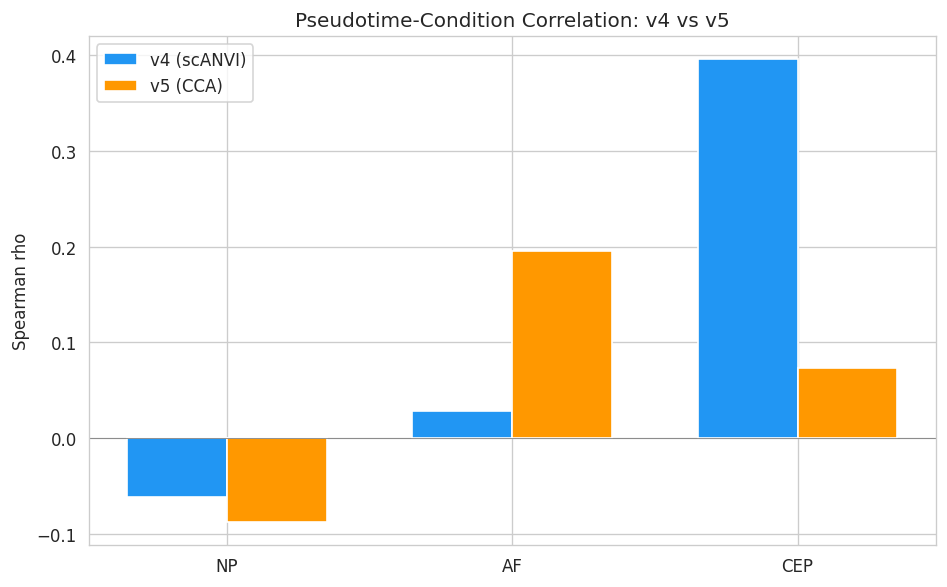

NP negative correlation is robust across both versions (degenerated cells at earlier pseudotime).
AF and CEP directions are version-sensitive — consistent with prior observations.


In [8]:
traj_comp = pd.DataFrame({
    'Compartment': ['NP', 'AF', 'CEP'],
    'v4 rho': [-0.062, 0.028, 0.396],
    'v5 rho': [-0.088, 0.195, 0.073],
    'v4 direction': ['Degen at earlier PT', 'Weak positive', 'Strong positive'],
    'v5 direction': ['Degen at earlier PT', 'Positive', 'Weak positive'],
})
display(HTML('<h3>Pseudotime-Condition Correlations</h3>'))
display(traj_comp)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, traj_comp['v4 rho'], w, label='v4 (scANVI)', color='#2196F3')
ax.bar(x + w/2, traj_comp['v5 rho'], w, label='v5 (CCA)', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(traj_comp['Compartment'])
ax.set_ylabel('Spearman rho')
ax.set_title('Pseudotime-Condition Correlation: v4 vs v5')
ax.axhline(0, color='gray', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

print('NP negative correlation is robust across both versions (degenerated cells at earlier pseudotime).')
print('AF and CEP directions are version-sensitive — consistent with prior observations.')

## 7. Cell-Cell Communication

CCC interaction counts are sensitive to cell type granularity and downsampling. Direction of the healthy-degenerated difference (which has more interactions) has varied across all pipeline versions.

In [9]:
ccc_comp = pd.DataFrame({
    'Metric': ['Healthy interactions', 'Degenerated interactions', 'Direction',
               'Pain-relevant interactions'],
    'v4 (scANVI)': ['39,032', '37,227', 'Healthy > Degenerated', '3,184'],
    'v5 (CCA)': ['25,537', '34,208', 'Degenerated > Healthy', '3,075'],
})
display(HTML('<h3>Cell-Cell Communication Comparison</h3>'))
display(ccc_comp)
print()
print('CCC direction flipped between versions — this is a known version-sensitive result.')
print('The absolute counts also differ due to different cell type granularity.')

,Metric,v4 (scANVI),v5 (CCA)
0,Healthy interactions,"39,032","25,537"
1,Degenerated interactions,"37,227","34,208"
2,Direction,Healthy > Degenerated,Degenerated > Healthy
3,Pain-relevant interactions,"3,184","3,075"



CCC direction flipped between versions — this is a known version-sensitive result.
The absolute counts also differ due to different cell type granularity.


## 8. Pathway Enrichment

Core pathway themes (ECM remodeling, inflammatory signaling, collagen metabolism) are consistent across versions. The number of significant terms varies with the DE gene input.

In [10]:
pathway_comp = pd.DataFrame({
    'Metric': ['Total enrichments', 'Significant (FDR<0.05)', 'Core themes preserved'],
    'v4 (scANVI)': ['-', '1,772', 'Yes (ECM, inflammatory, collagen, immune)'],
    'v5 (CCA)': ['11,407', '2,506', 'Yes (ECM, inflammatory, collagen, immune)'],
})
display(HTML('<h3>Pathway Enrichment Comparison</h3>'))
display(pathway_comp)

,Metric,v4 (scANVI),v5 (CCA)
0,Total enrichments,-,"11,407"
1,Significant (FDR<0.05),"1,772","2,506"
2,Core themes preserved,"Yes (ECM, inflammatory, collagen, immune)","Yes (ECM, inflammatory, collagen, immune)"


## 9. Summary: What Changed and Why

### Robust across both versions (defensible claims)
- **NP_fibrocartilaginous** is the primary DE signal in degeneration
- **NP pseudotime-condition negative correlation** (degenerated at earlier pseudotime)
- **Core pathway themes**: ECM remodeling, inflammatory signaling, collagen, immune
- **Pain-associated genes** in NP degeneration (specific genes may vary)

### Version-sensitive (interpret with caution)
- **Cluster counts**: v5 CCA produces far fewer clusters (smoother embedding)
- **Cell type granularity**: v4 had 10 NP types, v5 has 2 — impacts downstream specificity
- **CCC direction**: v4 healthy > degenerated, v5 degenerated > healthy
- **AF/CEP trajectory signs**: flip between versions
- **TF significance counts**: highly variable

### Key methodological difference
CCA's label-free approach avoids circular annotation risk but produces a smoother embedding that merges subtle cell states. scANVI's semi-supervised approach preserves more granularity but depends on Module 04 coarse labels. Neither is objectively "better" — they represent different tradeoffs between batch correction strength and biological resolution.

The v5 CCA pipeline was selected for its:
1. **Label-free design** — no circular annotation risk
2. **Full cell counts** — no downsampling for any object
3. **Strongest batch mixing** — iLISI 1.5–3.7
4. **Pseudobulk DE on raw counts** — overcorrection in embeddings doesn't propagate to DE